# 5. VQGAN + CLIP

Не обёртка над чужим `generate.py`, а короткий цикл: берём ImageNet VQGAN, оптимизируем латент так, чтобы CLIP-эмбеддинг декода совпал с текстом.

Кропы (cutouts) нужны, иначе CLIP залипает на глобальный артефакт и картинка «плывёт» в кашу.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from omegaconf import OmegaConf
from PIL import Image
from tqdm.auto import tqdm

# Encoder/Decoder из taming, без VQModel — тот тянет сломанный pytorch_lightning/torchmetrics
from taming.modules.diffusionmodules.model import Decoder, Encoder

try:
    from taming.modules.vqvae.quantize import VectorQuantizer2 as VectorQuantizer
except ImportError:
    from taming.modules.vqvae.quantize import VectorQuantizer

try:
    import clip
except ImportError:
    sys.path.insert(0, str(Path("vqgan_clip_env/lib/python3.9/site-packages").resolve()))
    import clip


class TinyVQGAN(nn.Module):
    """Только encode/decode. Loss/discriminator из чекпоинта не грузим."""

    def __init__(self, ddconfig, n_embed, embed_dim):
        super().__init__()
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)
        self.quantize = VectorQuantizer(n_embed, embed_dim, beta=0.25)
        self.quant_conv = nn.Conv2d(ddconfig["z_channels"], embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)

    def decode(self, quant):
        return self.decoder(self.post_quant_conv(quant))


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


ROOT = Path(".").resolve()
device = get_device()
OUT = ROOT / "runs" / "vqgan"
OUT.mkdir(parents=True, exist_ok=True)
print("device", device)


/Users/mnfom/Projects/cnn-Makarena-211/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device mps


In [2]:
def load_vqgan(config_path, ckpt_path):
    cfg = OmegaConf.load(config_path)
    dd = {k: (list(v) if k == "ch_mult" else v) for k, v in dict(cfg.model.params.ddconfig).items()}
    model = TinyVQGAN(
        ddconfig=dd,
        n_embed=int(cfg.model.params.n_embed),
        embed_dim=int(cfg.model.params.embed_dim),
    )
    blob = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = blob["state_dict"] if isinstance(blob, dict) and "state_dict" in blob else blob
    missing, unexpected = model.load_state_dict(sd, strict=False)
    # unexpected — обычно loss/discriminator
    print("loaded, missing", len(missing), "unexpected", len(unexpected))
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(device)


vqgan = load_vqgan(
    ROOT / "vqgan_models" / "vqgan_imagenet_f16_16384.yaml",
    ROOT / "vqgan_models" / "last.ckpt",
)
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
print("vqgan + clip ready")


Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded, missing 0 unexpected 55
vqgan + clip ready


In [3]:
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device)[:, None, None]
CLIP_STD = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device)[:, None, None]


def to_clip(img01, n_cuts=16):
    # img01: 1x3xHxW in [0,1]
    cuts = []
    H = img01.shape[-1]
    for _ in range(n_cuts):
        s = int(torch.randint(int(0.55 * H), H + 1, ()).item())
        y = int(torch.randint(0, H - s + 1, ()).item())
        x = int(torch.randint(0, H - s + 1, ()).item())
        crop = img01[:, :, y : y + s, x : x + s]
        cuts.append(F.interpolate(crop, (224, 224), mode="bicubic", align_corners=False))
    x = torch.cat(cuts, 0).clamp(0, 1)
    return (x - CLIP_MEAN) / CLIP_STD


def synth(h):
    quant, _, _ = vqgan.quantize(h)
    rgb = vqgan.decode(quant)
    return (rgb + 1) / 2


@torch.no_grad()
def encode_init(path, size=256):
    img = Image.open(path).convert("RGB").resize((size, size), Image.LANCZOS)
    x = torch.tensor(np.array(img), device=device).permute(2, 0, 1)[None] / 255.0
    x = x * 2 - 1
    h = vqgan.quant_conv(vqgan.encoder(x))
    return h


def generate(prompt, steps=120, seed=0, lr=0.12, init_path=None, n_cuts=12, size=256):
    torch.manual_seed(seed)
    np.random.seed(seed)
    f = 16
    if init_path is None:
        h = torch.randn(1, 256, size // f, size // f, device=device)
        h = h / 3  # чуть ближе к нулю, меньше цветного шума в начале
    else:
        h = encode_init(init_path, size=size)
    h = h.detach().requires_grad_(True)
    opt = torch.optim.Adam([h], lr=lr)

    with torch.no_grad():
        tok = clip.tokenize([prompt]).to(device)
        txt = clip_model.encode_text(tok).float()
        txt = txt / txt.norm(dim=-1, keepdim=True)

    hist = []
    for i in tqdm(range(steps), desc=prompt[:40]):
        img = synth(h).clamp(0, 1)
        cuts = to_clip(img, n_cuts=n_cuts)
        imf = clip_model.encode_image(cuts).float()
        imf = imf / imf.norm(dim=-1, keepdim=True)
        loss = (1 - (imf @ txt.T).mean()) + 0.0008 * h.pow(2).mean()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        hist.append(float(loss.detach()))
        if (i + 1) % max(steps // 4, 1) == 0:
            tqdm.write(f"  step {i+1} loss {hist[-1]:.4f}")
    with torch.no_grad():
        out = synth(h).clamp(0, 1)[0].cpu()
    return out, hist


In [4]:
jobs = [
    ("a studio photo of a fluffy samoyed dog face, sharp details", "samoyed.png", 21, None),
    ("a close-up of a sphynx cat, wrinkled skin, photorealistic", "sphynx.png", 8, None),
    ("watercolor painting of a ragdoll cat sleeping on a windowsill", "ragdoll_paint.png", 33, None),
]

results = []
for prompt, name, seed, init in jobs:
    img, hist = generate(prompt, steps=100, seed=seed, init_path=init)
    path = OUT / name
    Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype("uint8")).save(path)
    results.append((prompt, path, img, hist))
    print("saved", path)


a studio photo of a fluffy samoyed dog f:  25%|██▌       | 25/100 [09:03<26:46, 21.43s/it]

  step 25 loss 0.6830


a studio photo of a fluffy samoyed dog f:  50%|█████     | 50/100 [18:02<17:55, 21.50s/it]

  step 50 loss 0.5913


a studio photo of a fluffy samoyed dog f:  75%|███████▌  | 75/100 [27:01<08:59, 21.57s/it]

...

  step 50 loss 0.5854


watercolor painting of a ragdoll cat sle:  75%|███████▌  | 75/100 [26:56<09:00, 21.64s/it]

  step 75 loss 0.5396


watercolor painting of a ragdoll cat sle: 100%|██████████| 100/100 [35:44<00:00, 21.45s/it]

  step 100 loss 0.5333
saved /Users/mnfom/Projects/cnn-Makarena-211/runs/vqgan/ragdoll_paint.png


Init image: стартуем от реальной сибы и тянем текст. Это не инпейнт, латент просто съезжает в сторону промпта.


In [5]:
import petsdata as P

train_df, _, _, _ = P.ensure_splits()
init = Path(train_df[train_df["breed"] == "shiba_inu"]["path"].iloc[0])
print("init", init)

prompt = "a cyberpunk neon portrait of a shiba inu, cinematic lighting"
img, hist = generate(prompt, steps=80, seed=5, lr=0.08, init_path=init)
path = OUT / "shiba_neon.png"
Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype("uint8")).save(path)
results.append((prompt, path, img, hist))


init /Users/mnfom/Projects/cnn-Makarena-211/petfaces/dog_shiba/shiba_inu_107.jpg


a cyberpunk neon portrait of a shiba inu:  25%|██▌       | 20/80 [07:03<21:10, 21.18s/it]

  step 20 loss 0.5808


a cyberpunk neon portrait of a shiba inu:  50%|█████     | 40/80 [14:07<14:07, 21.19s/it]

  step 40 loss 0.5593


a cyberpunk neon portrait of a shiba inu:  75%|███████▌  | 60/80 [21:10<07:03, 21.16s/it]

  step 60 loss 0.5209


a cyberpunk neon portrait of a shiba inu: 100%|██████████| 80/80 [28:19<00:00, 21.24s/it]

  step 80 loss 0.5292


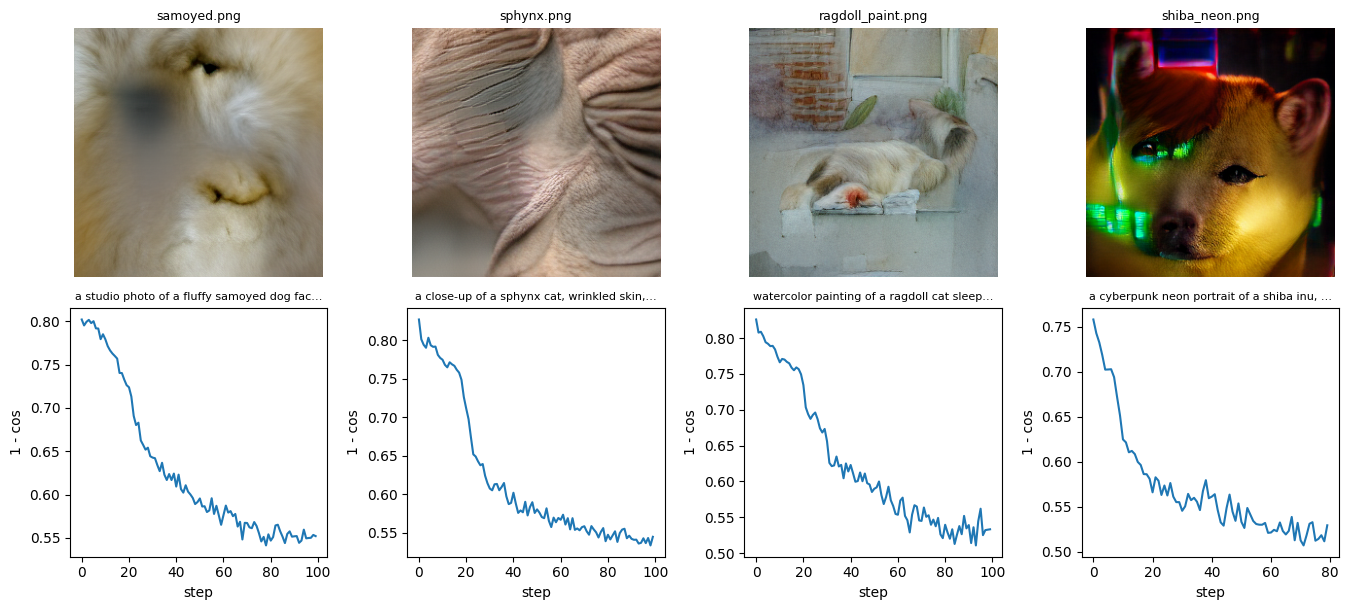

In [6]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 6.2))
if n == 1:
    axes = np.array(axes).reshape(2, 1)
for i, (prompt, path, img, hist) in enumerate(results):
    axes[0, i].imshow(img.permute(1, 2, 0))
    axes[0, i].set_title(path.name, fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].plot(hist)
    axes[1, i].set_title(prompt[:42] + ("…" if len(prompt) > 42 else ""), fontsize=8)
    axes[1, i].set_xlabel("step")
    axes[1, i].set_ylabel("1 - cos")
plt.tight_layout()
plt.show()
